In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRanker
from xgboost import XGBRanker
from catboost import CatBoostRanker
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
USD = 1.0
EUR = 1.2
IRR = 1/40200

categorical_cols= ["company_size", "remote_allowed", "willing_to_relocate", 
                    "industry", "job_location", "candidate_location"]

In [ ]:
def merge_df(applications, candidates, jobs):
  df= applications.merge(jobs, on="job_id")
  df= df.merge(candidates, on="candidate_id")
  return df

In [62]:
def salary_currency_handler(df):
  df["salary_min"]= df["salary_min"].astype(float)
  df["salary_max"]= df["salary_max"].astype(float)
  df.loc[df["salary_max"]<0, "salary_max"]= np.nan
  irr_mask= df["salary_currency"]=="irr"
  eur_mask= df["salary_currency"]=="eur"
  df.loc[irr_mask, "salary_min"]*= IRR
  df.loc[irr_mask, "salary_max"]*= IRR
  df.loc[eur_mask, "salary_min"]*= EUR
  df.loc[eur_mask, "salary_max"]*= EUR
  df.loc[irr_mask|eur_mask, "salary_currency"]="usd"
  return df

In [ ]:
def clean_df(df):
    df = df.copy()
    df.loc[df["min_years_experience"] < 0, "min_years_experience"] = np.nan
    df["job_posted_date"] = pd.to_datetime(df["job_posted_date"], dayfirst=True, errors="coerce")
    df["account_created_date"] = pd.to_datetime(df["account_created_date"], dayfirst=True, errors="coerce")
    df["application_date"] = pd.to_datetime(df["application_date"], dayfirst=True, errors="coerce")

    education_map = {"HS": 0, "Secondary": 0, "B.S.": 1, "B.A.": 1, "BSc": 1, "M.A.": 2,
                     "M.S.": 2, "MSc": 2, "Ph.D.": 3, "Doctorate": 3, "High School": 0,
                     "Bachelor": 1, "Master": 2, "PhD": 3}
    df["education_level"] = df["education_level"].replace(education_map)
    
    proficiency_map = {"Beginner": 0, "Elementary": 2, "Intermediate": 3, "Upper-Intermediate": 4,
                       "Advanced": 5, "Bilingual": 6, "Fluent": 4, "A1": 0, "A2": 1, "B1": 2,
                       "B2": 3, "C1": 4, "C2": 5, "Native": 6}
    df["english_proficiency"] = df["english_proficiency"].replace(proficiency_map)
    
    company_size_map = {"201-1000": "large", "51-200": "medium", "1000+": "large",
                        "11-50": "small", "1-10": "small"}
    df["company_size"] = df["company_size"].replace(company_size_map)
    
    str_columns = df.select_dtypes(include="object").columns
    for col in str_columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
    
    df["current_title"]= df["current_title"].str.replace("jr.", "junior", regex=False)
    df["current_title"]= df["current_title"].str.replace("sr.", "senior", regex=False)
    df["job_title"]= df["job_title"].str.replace("jr.", "junior", regex=False)
    df["job_title"]= df["job_title"].str.replace("sr.", "senior", regex=False)
    
    df = df.sort_values(by="application_date")
    df = salary_currency_handler(df)
    return df

In [ ]:
def fit_null_stats(df):
    stats = {
        "min_years_experience": df["min_years_experience"].median(),
        "max_years_experience": df["max_years_experience"].median(),
        "english_proficiency": df["english_proficiency"].mode()[0] if len(df["english_proficiency"].mode()) > 0 else 3,
        "salary_min_median": df["salary_min"].median(),
        "salary_max_median": df["salary_max"].median(),
    }
    return stats

In [ ]:
def fill_null(df, stats):
    df = df.copy()
    df["min_years_experience"] = df["min_years_experience"].fillna(stats["min_years_experience"])
    df["max_years_experience"] = df["max_years_experience"].fillna(stats["max_years_experience"])
    df["company_size"] = df["company_size"].fillna("unknown")
    df["university"] = df["university"].fillna("unknown")
    df["previous_companies"] = df["previous_companies"].fillna("")
    df["willing_to_relocate"] = df["willing_to_relocate"].fillna("unknown")
    df["remote_allowed"] = df["remote_allowed"].fillna("unknown")
    df["years_experience"] = df["years_experience"].fillna(0)
    df["english_proficiency"] = df["english_proficiency"].fillna(stats["english_proficiency"])
    df["required_skills"] = df["required_skills"].fillna("")
    df["skills"] = df["skills"].fillna("")
  
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).astype("category")
    return df

In [ ]:
def create_basic_features(df):
    df = df.copy()
    df["experience_gap"]= df["years_experience"] - df["min_years_experience"]
    df["meet_experience_range"]= ((df["years_experience"] >= df["min_years_experience"]) & 
                                   (df["years_experience"] <= df["max_years_experience"])).astype(int)
    
    df["location_match"]= (df["job_location"] == df["candidate_location"]).astype(int)
    df["location_compatibility"]= (df["location_match"] | 
                                   (df["willing_to_relocate"] == 1) | 
                                   (df["remote_allowed"] == 1)).astype(int)
    
    df["certifications"]= df["certifications"].fillna("")
    df["num_certificates"]= (df["certifications"].str.split("|").apply(lambda x: len([s.strip() for s in x if s.strip()])))
    df["num_previous_companies"] = df["previous_companies"].str.split("|").str.len()
    
    df["account_age"]= (df["application_date"] - df["account_created_date"]).dt.days.fillna(0).astype(int)
    
    df["required_skills_list"]= df["required_skills"].str.split("|").apply(lambda x: [s.strip() for s in x if s.strip()])
    df["skills_list"]= df["skills"].str.split("|")
    req_set= df["required_skills_list"].apply(set)
    cand_set= df["skills_list"].apply(set)
    df["skill_overlap_ratio"]= req_set.combine(cand_set, lambda x, relevance_label: len(x & relevance_label) / len(x) if len(x) > 0 else 0)
    df["req_skill_count"]= df["required_skills_list"].apply(lambda x: 0 if x == [""] else len(x))
    df["cand_skill_count"]= df["skills_list"].apply(lambda x: 0 if x == [""] else len(x))
    df["skill_count_diff"]= df["cand_skill_count"] - df["req_skill_count"]
    df["job_posted_year"]= df["job_posted_date"].dt.year
    df["job_posted_month"]= df["job_posted_date"].dt.month
    df["job_posted_day"]= df["job_posted_date"].dt.day
    
    df["application_year"]= df["application_date"].dt.year
    df["application_month"]= df["application_date"].dt.month
    df["application_day"]= df["application_date"].dt.day
    df["days_since_posting"]= (df["application_date"] - df["job_posted_date"]).dt.days
    
    return df

In [ ]:
def create_advanced_features(df, null_stats):
    df = df.copy()
    title_keywords= ["senior", "junior", "lead", "manager", "engineer", "developer",
                     "analyst", "scientist", "architect", "consultant", "director",
                     "principal", "staff", "intern"]
    
    for kw in title_keywords:
        df[f"job_has_{kw}"]= df["job_title"].fillna("").str.contains(kw).astype(int)
        df[f"cand_has_{kw}"]= df["current_title"].fillna("").str.contains(kw).astype(int)
    df["title_keyword_overlap"] = 0
    for kw in title_keywords:
        df["title_keyword_overlap"]+= (df[f"job_has_{kw}"] & df[f"cand_has_{kw}"]).astype(int)
    salary_min_filled= df["salary_min"].fillna(null_stats["salary_min_median"])
    salary_max_filled= df["salary_max"].fillna(null_stats["salary_max_median"])
    df["salary_midpoint"]= (salary_min_filled + salary_max_filled)/2

    df["education_level"]= pd.to_numeric(df["education_level"], errors="coerce").fillna(0)
    df["job_min_education"]= pd.factorize(df["job_title"].str.extract("(master|phd|mba)", expand=False))[0]
    edu_req = {"master": 2, "mba": 2, "phd": 3}
    tmp = df["job_title"].str.extract("(master|phd|mba)", expand=False)
    df["job_min_education"]= tmp.map(edu_req).fillna(0)
    
    df["fresh_application"]= (df["days_since_posting"] <= 7).astype(int)
    df["very_fresh_application"]= (df["days_since_posting"] <= 2).astype(int)
    df["stale_application"]= (df["days_since_posting"] > 60).astype(int)

    df["old_account"]= (df["account_age"] > 365).astype(int)
    df["established_account"]= (df["account_age"] > 730).astype(int)
    df["brand_new_account"]= (df["account_age"] < 7).astype(int)

    df["needs_relocation"]= ((df["location_match"]==0) & (df["willing_to_relocate"]==0)).astype(int)
    df["requires_onsite"]= ((df["remote_allowed"]==0)).astype(int)
    df["has_mobility_issue"]= ((df["needs_relocation"]) & (df["requires_onsite"])).astype(int)
        
    df["experienced_and_located"]= df["meet_experience_range"]*df["location_compatibility"]        
    job_title_counts= df["job_title"].value_counts()
    df["job_title_commonality"]= df["job_title"].map(lambda x: job_title_counts.get(x, 0)/len(df))
    
    df["company_size_preference_match"]= 0
    req_set= df["required_skills_list"].apply(set)
    cand_set= df["skills_list"].apply(set)
    df["skill_recall"]= req_set.combine(cand_set, lambda r, c: len(r&c)/len(r) if len(r) > 0 else 0)
    df["skill_precision"]= req_set.combine(cand_set, lambda r, c: len(r&c)/len(c) if len(c) > 0 else 0)
    df["skill_jaccard"]= req_set.combine(cand_set, lambda r, c: len(r&c)/len(r|c) if len(r|c) > 0 else 0)
    df["is_impossible_match"]= ((df["remote_allowed"] == 0) & (df["job_location"] != df["candidate_location"]) & (df["willing_to_relocate"] == 0)).astype(int)
    df["location_aligned"]= ((df["remote_allowed"] == 1) | (df["job_location"] == df["candidate_location"])).astype(int)
    df["exp_rank_in_job"]= (
    df.groupby("job_id")["years_experience"].rank(pct=True))
    df["skill_rank_in_job"]= (df.groupby("job_id")["skill_overlap_ratio"].rank(pct=True))
    df["exp_above_min"]= (
    df["years_experience"]-df["min_years_experience"]).clip(lower=0)
    df["exp_below_min"]= (df["min_years_experience"] - df["years_experience"]).clip(lower=0)
    df["exp_ratio"]= (df["years_experience"]/(df["min_years_experience"] + 1))
    df["salary_within_range"]= ((df["expected_salary"] >= df["salary_min"])&(df["expected_salary"] <= df["salary_max"])).astype(int)
    df["expected_vs_midpoint_ratio"]= df["expected_salary"] / (df["salary_midpoint"] + 1)
    df["expected_above_max"]= (df["expected_salary"] > df["salary_max"]).astype(int)
    df["education_gap"]= df["education_level"] - df["job_min_education"]
    df["education_meets_req"]= (df["education_level"] >= df["job_min_education"]).astype(int)
    df["skill_x_exp_match"] = df["skill_overlap_ratio"] * df["meet_experience_range"]
    df["composite_fit"]= (0.4*df["skill_overlap_ratio"] + 0.3*df["meet_experience_range"]+0.2*df["location_compatibility"] + 0.1*df["education_meets_req"])
    df["salary_within_range"]= ((df["expected_salary"] >= salary_min_filled) & (df["expected_salary"] <= salary_max_filled)).astype(int)
    df["expected_vs_midpoint_ratio"] = df["expected_salary"] / (df["salary_midpoint"] + 1)
    df["expected_above_max"]= (df["expected_salary"] > salary_max_filled).astype(int)
    df["expected_below_min"]= (df["expected_salary"] < salary_min_filled).astype(int)
    df["salary_overshoot"]= (df["expected_salary"] - salary_max_filled).clip(lower=0)
    df["salary_undershoot"]= (salary_min_filled - df["expected_salary"]).clip(lower=0)
    return df

In [ ]:
def create_fold_features(df_train, df_val):
    job_salary_stats = (df_train.groupby("job_id")["expected_salary"]
                        .agg(job_salary_mean="mean", job_salary_std="std")
                        .reset_index())
    job_exp_stats = (df_train.groupby("job_id")["years_experience"]
                     .agg(job_exp_mean="mean")
                     .reset_index())
    job_app_count = (df_train.groupby("job_id")["application_id"]
                     .count().rename("job_application_count").reset_index())
    cand_app_count = (df_train.groupby("candidate_id")["application_id"]
                      .count().rename("candidate_apply_count").reset_index())

    def _apply(df):
        df = df.copy()
        df = df.merge(job_salary_stats, on="job_id", how="left")
        df = df.merge(job_exp_stats, on="job_id", how="left")
        df = df.merge(job_app_count, on="job_id", how="left")
        df = df.merge(cand_app_count, on="candidate_id", how="left")
        df["job_application_count"]= df["job_application_count"].fillna(0)
        df["candidate_apply_count"]= df["candidate_apply_count"].fillna(0)
        df["job_salary_std"]= df["job_salary_std"].fillna(0)
        df["salary_diff_from_job_avg"]= (df["expected_salary"]- df["job_salary_mean"].fillna(df["expected_salary"]))
        df["salary_rank_in_job"]= (df.groupby("job_id")["expected_salary"].rank(pct=True))
        df["exp_rank_in_job"]= (df.groupby("job_id")["years_experience"].rank(pct=True))
        df["skill_rank_in_job"]= (df.groupby("job_id")["skill_overlap_ratio"].rank(pct=True))
        return df

    return _apply(df_train, True), _apply(df_val, False)

In [69]:
def drop_columns(df):
    drop_cols = ["required_skills", "skills", "university", "previous_companies",
                 "certifications", "job_posted_date", "account_created_date",
                 "required_skills_list", "skills_list", "salary_currency",
                 "candidate_id", "application_date", "job_title", "current_title"]
    df = df.drop([c for c in drop_cols if c in df.columns], axis=1)
    return df

In [70]:
jobs= pd.read_csv("task 3 - datasets/jobs.csv")
candidates= pd.read_csv("task 3 - datasets/candidates.csv")
applications_train= pd.read_csv("task 3 - datasets/applications_train.csv")
df = merge_df(applications_train, candidates, jobs)

In [71]:
df.head()

,application_id,job_id,candidate_id,application_date,relevance_label,job_title,required_skills,min_years_experience,max_years_experience,salary_min,...,education_level,university,previous_companies,certifications,english_proficiency,expected_salary,candidate_location,willing_to_relocate,profile_completeness,account_created_date
0,206,6,31050,2023-11-26,2,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Master,Generic State University 27,Generic Tech Co 18|Stripe|Generic Tech Co 52|G...,Azure-AZ305,NaN,116655.275330,Istanbul,NaN,89,2023-01-07
1,207,6,19239,2023-11-16,1,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,PhD,Online University A,Generic Tech Co 24|Generic Tech Co 56|Generic ...,NaN,C1,86966.039783,London,NaN,88,2020-07-29
2,208,6,34280,2023-11-26,2,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Bachelor,NaN,NaN,NaN,B1,91955.832040,Berlin,No,64,2022-05-19
3,209,6,42881,2023-11-26,1,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Bachelor,Stanford University,NaN,Kubernetes-CKAD|Azure-AZ104|GCP-ACE,A2,59774.450025,Tabriz,Yes,91,2023-04-13
4,210,6,2777,2023-11-16,0,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Master,NaN,Generic Tech Co 2|Generic Tech Co 77,NaN,Beginner,51165.932462,Munich,Yes,73,2022-09-15


In [72]:
df.describe()

,application_id,job_id,candidate_id,relevance_label,min_years_experience,max_years_experience,salary_min,salary_max,years_experience,expected_salary,profile_completeness
count,118772.000000,118772.000000,118772.000000,118772.000000,116509.000000,107631.000000,1.187720e+05,1.187720e+05,109054.000000,118772.000000,118772.000000
mean,93179.241892,2507.655912,25038.454223,1.148789,5.430344,9.458623,5.281544e+08,6.894193e+08,5.974811,97184.797347,84.152031
std,53854.886160,1453.416679,14417.824563,1.129433,4.191487,4.371679,1.513980e+09,1.991958e+09,4.238885,35834.971609,11.309889
min,206.000000,6.000000,1.000000,0.000000,-1.000000,1.000000,2.800000e+04,3.200000e+04,0.000000,20000.000000,33.000000
25%,45944.000000,1233.500000,12608.750000,0.000000,2.000000,6.000000,5.800000e+04,7.300000e+04,3.000000,73299.379971,75.000000
50%,93695.500000,2510.000000,25009.500000,1.000000,5.000000,9.000000,1.000000e+05,1.230000e+05,5.000000,92221.065257,87.000000
75%,139488.250000,3751.000000,37539.000000,2.000000,9.000000,13.000000,1.420000e+05,1.940000e+05,8.000000,114130.183735,91.000000
max,185505.000000,5000.000000,50000.000000,4.000000,15.000000,21.000000,9.240000e+09,1.307000e+10,25.000000,293429.495318,100.000000


In [73]:
missing= df.isnull().sum()
missing_pct= (missing/len(df)*100).round(2)
missing_df= pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df= missing_df[missing_df["Missing Count"]>0].sort_values("Missing %", ascending=False)
print(missing_df)

                      Missing Count  Missing %
certifications                66960      56.38
previous_companies            32019      26.96
university                    29488      24.83
willing_to_relocate           18137      15.27
english_proficiency           12220      10.29
max_years_experience          11141       9.38
years_experience               9718       8.18
company_size                   9009       7.59
remote_allowed                 6439       5.42
required_skills                5635       4.74
min_years_experience           2263       1.91


In [74]:
non_numberic_columns= df.select_dtypes(exclude=["int64", "float64"]).columns
df[non_numberic_columns].describe()

,application_date,job_title,required_skills,salary_currency,job_location,remote_allowed,job_posted_date,company_size,industry,current_title,skills,education_level,university,previous_companies,certifications,english_proficiency,candidate_location,willing_to_relocate,account_created_date
count,118772,118772,113137,118772,118772,112333,118772,109763,118772,118772,118772,118772,89284,86753,51812,106552,118772,100635,118772
unique,547,162,3491,12,96,3,624,5,25,200,44312,14,142,25203,5049,14,140,2,1522
top,2024-06-25,Solutions Architect (Senior),XGBoost|Git|dbt|dbt,USD,Tabriz,No,2023-03-05,201-1000,Energy,VP Engineering,REST API|RabbitMQ|Power BI|Communication|Java|...,Bachelor,Online University R,Google,Azure-AZ305,A2,Singapore,No,2022-02-16
freq,321,3853,150,71959,5196,56474,537,33139,5971,3148,13,58055,753,184,705,15162,4320,60549,151


C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\547047880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='relevance_label', palette='viridis')


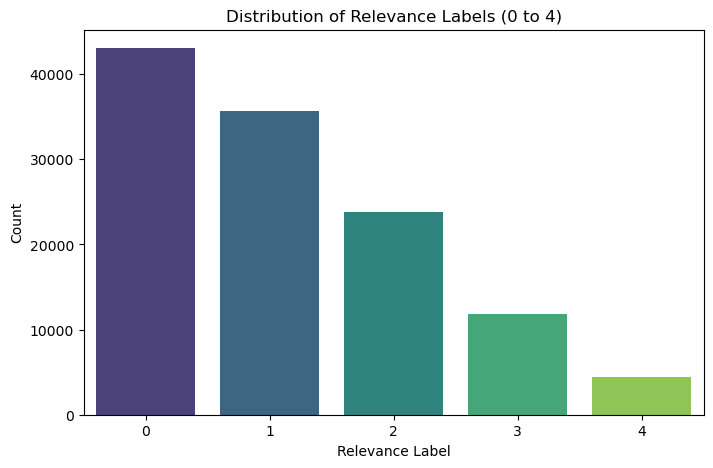

In [75]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="relevance_label", palette="viridis")
plt.title("Distribution of Relevance Labels (0 to 4)")
plt.xlabel("Relevance Label")
plt.ylabel("Count")
plt.show()

C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\340982225.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=raw_correlations.values, y=raw_correlations.index, palette='coolwarm_r')


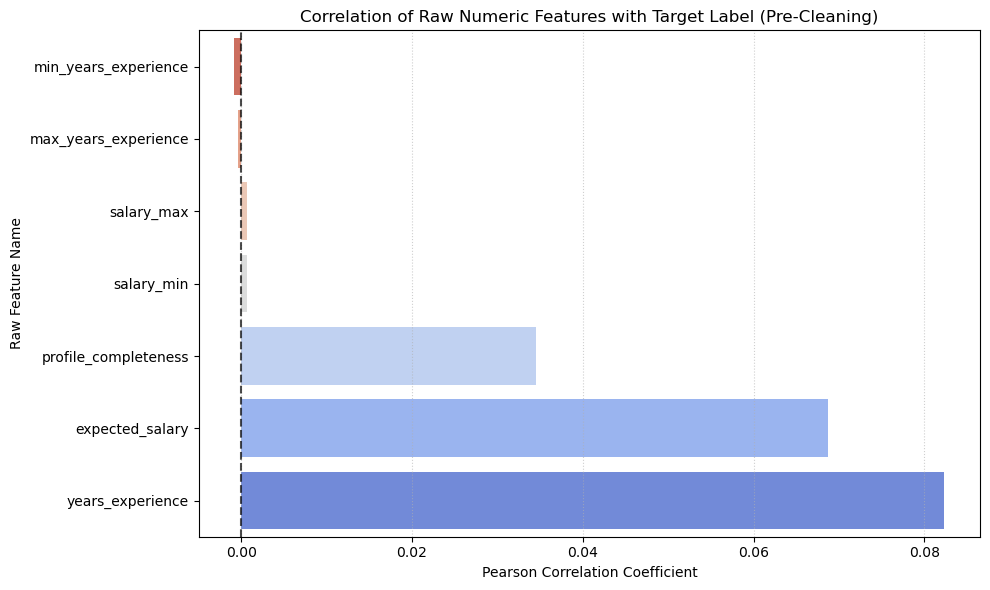

In [76]:
numeric_raw = df.select_dtypes(include=["number"])

ids_to_exclude = [c for c in ["application_id", "job_id", "candidate_id"] if c in numeric_raw.columns]
numeric_raw = numeric_raw.drop(columns=ids_to_exclude)

raw_correlations = numeric_raw.corr()["relevance_label"].drop("relevance_label").sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=raw_correlations.values, y=raw_correlations.index, palette="coolwarm_r")
plt.title("Correlation of Raw Numeric Features with Target Label (Pre-Cleaning)")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Raw Feature Name")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [77]:
df = clean_df(df)
null_stats = fit_null_stats(df)
df = fill_null(df, null_stats)
df = create_basic_features(df)
df = create_advanced_features(df, null_stats)
df = drop_columns(df)

C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312109484.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["application_date"] = pd.to_datetime(df["application_date"], dayfirst=True, errors="coerce")
C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312109484.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["education_level"] = df["education_level"].replace(education_map)
C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312109484.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the f

C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\1450088408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='relevance_label', y='skill_overlap_ratio', ax=axes[0], palette='viridis')
C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\1450088408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='relevance_label', y='experience_gap', ax=axes[1], palette='viridis')


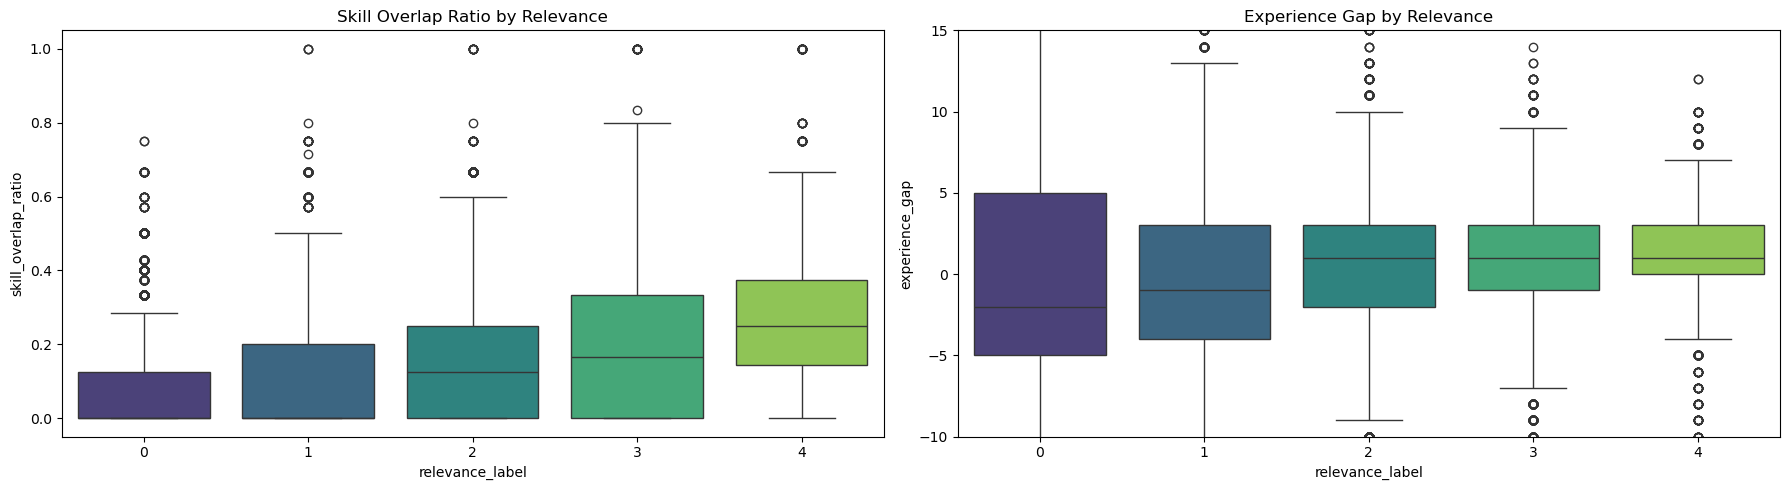

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(data=df, x="relevance_label", y="skill_overlap_ratio", ax=axes[0], palette="viridis")
axes[0].set_title("Skill Overlap Ratio by Relevance")

sns.boxplot(data=df, x="relevance_label", y="experience_gap", ax=axes[1], palette="viridis")
axes[1].set_title("Experience Gap by Relevance")
axes[1].set_ylim(-10, 15)

plt.tight_layout()
plt.show()

In [79]:
groups= df["job_id"]
group_kfold= GroupKFold(n_splits=5)
drop_cols= ["relevance_label", "application_id", "job_id"]
X= df.drop(columns=drop_cols)
y= df["relevance_label"]

oof_lgbm= np.zeros(len(df))
oof_xgb= np.zeros(len(df))
oof_cat= np.zeros(len(df))

In [80]:
def ndcg_at_10(y_true, preds, groups):
    scores = []
    eval_df = pd.DataFrame({
        "job_id": groups,
        "y_true": y_true,
        "pred": preds
    })
    for _, group in eval_df.groupby("job_id"):
      if len(group)<2:
          continue
      score = ndcg_score(
          [group["y_true"].values],
          [group["pred"].values],
          k=10
      )
      scores.append(score)
    return np.mean(scores)

In [ ]:
def map_at_5(y, p, g):
    y= np.asarray(y)
    p= np.asarray(p)
    g= np.asarray(g)
    idx= np.argsort(g)
    y, p, g= y[idx], p[idx], g[idx]
    split= np.where(g[1:] != g[:-1])[0] + 1
    ys= np.split(y, split)
    ps= np.split(p, split)

    scores = []
    for yt, pr in zip(ys, ps):
        k = min(5, len(yt))
        top = np.argsort(pr)[::-1][:k]
        relevant_total = np.sum(yt >= 3)
        if relevant_total == 0:
            scores.append(0.0)
            continue
        hits= 0
        ap= 0.0
        for i, idx_val in enumerate(top, 1):
            if yt[idx_val] >= 3:   
                hits+= 1
                ap+= hits/i
        scores.append(ap/min(relevant_total, 5))
    return np.mean(scores)


In [82]:
cat_features= [c for c in categorical_cols if c in X.columns]
lg_model= LGBMRanker(objective="rank_xendcg", n_estimators=800, learning_rate=0.04, num_leaves=63, colsample_bytree=0.8, subsample=0.8, min_child_samples=20, label_gain=[0, 1, 2, 3, 4])
xgb_model= XGBRanker(objective="rank:ndcg", n_estimators=800, learning_rate=0.04, max_depth=6, colsample_bytree=0.8, subsample=0.8, enable_categorical=True)
cat_model= CatBoostRanker(loss_function="YetiRankPairwise", iterations=900, learning_rate=0.04, depth=6, l2_leaf_reg=3)

In [83]:
scores= []
for fold, (train_idx, val_idx) in enumerate(group_kfold.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    groups_train = groups.iloc[train_idx]
    groups_val = groups.iloc[val_idx]
    train_df = pd.concat([X_train, y_train, groups_train.rename("group_id")], axis=1).sort_values("group_id")
    train_df = train_df.sort_values("group_id")
    
    X_train_sorted = train_df.drop(columns=["group_id", "relevance_label"])
    y_train_sorted = train_df["relevance_label"]
    train_groups = train_df.groupby("group_id", sort=False).size().values
    lg_model.fit(X_train_sorted, y_train_sorted, group=train_groups)
    oof_lgbm[val_idx] = lg_model.predict(X_val)
    
    xgb_model.fit(X_train_sorted, y_train_sorted, group=train_groups)
    oof_xgb[val_idx] = xgb_model.predict(X_val)
    
    cat_model.fit(X_train_sorted, y_train_sorted, group_id=train_df["group_id"], cat_features=cat_features)
    oof_cat[val_idx] = cat_model.predict(X_val)
    
    fold_preds = (oof_lgbm[val_idx] + oof_xgb[val_idx] + oof_cat[val_idx]) / 3
    fold_score = ndcg_at_10(y_true=y_val, preds=fold_preds, groups=groups_val)
    scores.append(fold_score)
    
print("Mean NDCG@10:", np.mean(scores))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3776
[LightGBM] [Info] Number of data points in the train set: 95017, number of used features: 85
Pairwise scoring loss functions on CPU do not support one hot features. OneHotMaxSize set to 1
0:	total: 307ms	remaining: 4m 35s
1:	total: 524ms	remaining: 3m 55s
2:	total: 741ms	remaining: 3m 41s
3:	total: 955ms	remaining: 3m 33s
4:	total: 1.18s	remaining: 3m 30s
5:	total: 1.4s	remaining: 3m 28s
6:	total: 1.63s	remaining: 3m 27s
7:	total: 1.85s	remaining: 3m 26s
8:	total: 2.07s	remaining: 3m 25s
9:	total: 2.29s	remaining: 3m 24s
10:	total: 2.52s	remaining: 3m 23s
11:	total: 2.73s	remaining: 3m 22s
12:	total: 2.95s	remaining: 3m 21s
13:	total: 3.18s	remaining: 3m 21s
14:	total: 3.4s	remaining: 3m 20s
15:	total: 3.62s	remaining: 3m 19s
16:	

In [84]:
best_score= -1
best_weights= None
for w1 in np.arange(0, 1.01, 0.05):
    for w2 in np.arange(0, 1 - w1 + 0.01, 0.05):
        w3= 1-w1-w2
        preds= w1*oof_lgbm+w2*oof_xgb+ w3*oof_cat
        score= ndcg_at_10(y, preds, groups)
        if score > best_score:
            best_score= score
            best_weights= (w1, w2, w3)
print(f"Best NDCG@10: {best_score:.6f}")
print(f"Best weights: {best_weights}")

Best NDCG@10: 0.880441
Best weights: (np.float64(1.0), np.float64(0.0), np.float64(0.0))


In [85]:
final_oof= (best_weights[0]*oof_lgbm+best_weights[1]*oof_xgb+best_weights[2]*oof_cat)
overall_ndcg = ndcg_at_10(y_true=y, preds=final_oof, groups=groups)
overall_map5 = map_at_5(y, final_oof, groups)
print(f"Overall OOF MAP@5: {overall_map5}")
print("Overall OOF NDCG@10:", overall_ndcg)

Overall OOF MAP@5: 0.6428906463048812
Overall OOF NDCG@10: 0.8804412483525097


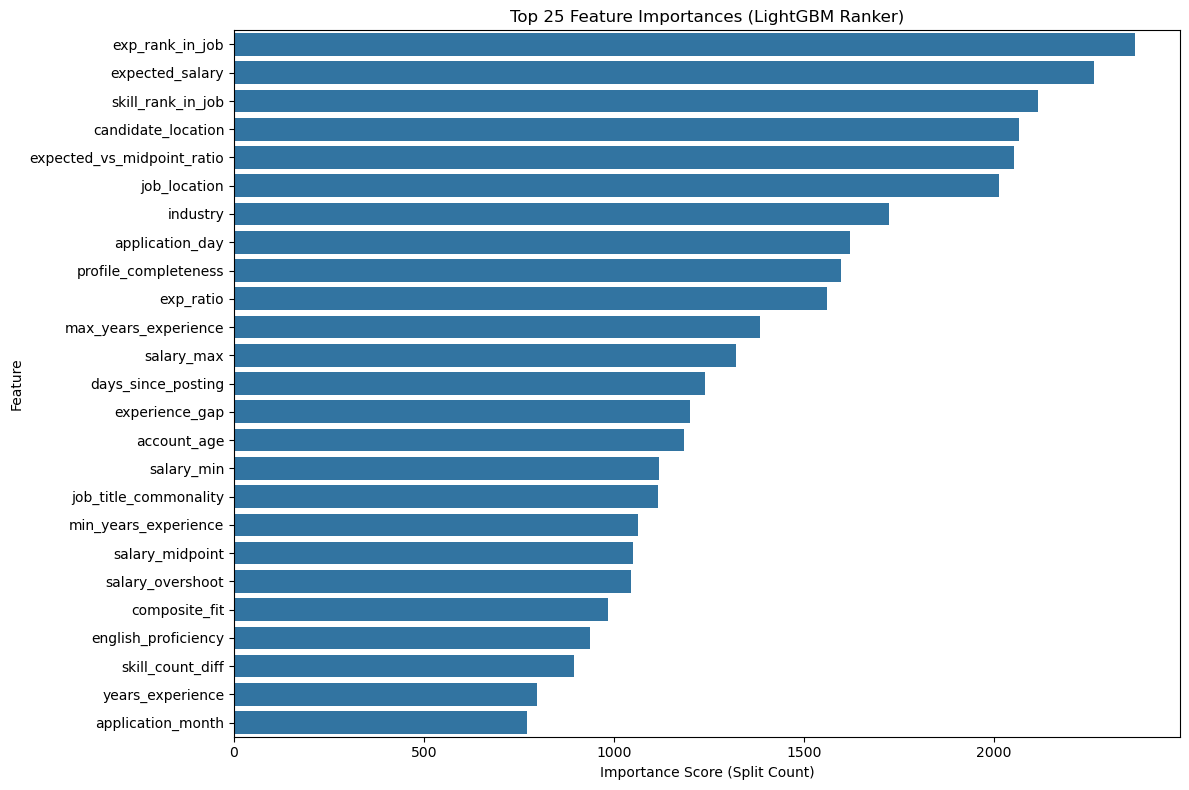

In [86]:
feat_importance= pd.DataFrame({"Feature": X.columns, "Importance": lg_model.feature_importances_}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_importance.head(25), x="Importance", y="Feature")
plt.title("Top 25 Feature Importances (LightGBM Ranker)")
plt.xlabel("Importance Score (Split Count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [87]:
df = df.sort_values("job_id")
drop_cols= ["relevance_label", "application_id", "job_id"]
X= df.drop(columns=drop_cols) 
y= df["relevance_label"]
groups= df["job_id"]
train_groups_full= df.groupby("job_id", sort=False)["job_id"].count().values

lg_model.fit(X, y, group=train_groups_full)
xgb_model.fit(X, y, group=train_groups_full)
cat_model.fit(X, y, group_id=groups, cat_features=cat_features)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3789
[LightGBM] [Info] Number of data points in the train set: 118772, number of used features: 85
Pairwise scoring loss functions on CPU do not support one hot features. OneHotMaxSize set to 1
0:	total: 375ms	remaining: 5m 37s
1:	total: 751ms	remaining: 5m 37s
2:	total: 1.11s	remaining: 5m 31s
3:	total: 1.48s	remaining: 5m 32s
4:	total: 1.85s	remaining: 5m 31s
5:	total: 2.21s	remaining: 5m 29s
6:	total: 2.6s	remaining: 5m 31s
7:	total: 2.96s	remaining: 5m 30s
8:	total: 3.37s	remaining: 5m 33s
9:	total: 3.74s	remaining: 5m 33s
10:	total: 4.13s	remaining: 5m 33s
11:	total: 4.49s	remaining: 5m 32s
12:	total: 4.86s	remaining: 5m 31s
13:	total: 5.22s	remaining: 5m 30s
14:	total: 5.6s	remaining: 5m 30s
15:	total: 6s	remaining: 5m 31s
16:	to

CatBoostRanker(depth=6, iterations=900, l2_leaf_reg=3, learning_rate=0.04, loss_function='YetiRankPairwise')

In [88]:
applications_test= pd.read_csv("task 3 - datasets/applications_test.csv")
df_test= merge_df(applications_test, candidates, jobs)
df_test= clean_df(df_test)
df_test= fill_null(df_test, null_stats)
df_test= create_basic_features(df_test)
df_test= create_advanced_features(df_test, null_stats)
df_test= drop_columns(df_test)
X_test= df_test.drop(columns=["application_id", "job_id"])

pred_lgbm= lg_model.predict(X_test)
pred_xgb= xgb_model.predict(X_test)
pred_cat= cat_model.predict(X_test)

final_score= (best_weights[0]*pred_lgbm+best_weights[1]*pred_xgb+best_weights[2]*pred_cat)

C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312109484.py:4: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["job_posted_date"] = pd.to_datetime(df["job_posted_date"], dayfirst=True, errors="coerce")
C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312109484.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["account_created_date"] = pd.to_datetime(df["account_created_date"], dayfirst=True, errors="coerce")
C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312109484.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["application_date"] = pd.to_datetime(df["application_date"], dayfirst=True, errors="coerce")
C:\Users\alireza\AppData\Local\Temp\ipykernel_22596\312

In [89]:
df_test["score"] = final_score
submission = df_test[["application_id", "score"]].copy()
submission.to_csv("submission3.csv", index=False)